<a href="https://colab.research.google.com/github/monteirotadeu-lgtm/Trabalho_Big_Python_/blob/main/Trabalho_1_Educacao_X_Criminalidade_CSV_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BASE DE DADOS DE SEGURANÇA PÚBLICA — ISP-RJ

In [ ]:
# Instalação das bibliotecas necessárias
!pip install pandas numpy matplotlib seaborn scipy scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais dos gráficos
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')
CORES = {'Rio de Janeiro': '#E63946', 'Niterói': '#2196F3', 'São Gonçalo': '#4CAF50'}

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


In [ ]:
# CARREGAMENTO DA BASE DO ISP-RJ via link direto
# Fonte oficial: Instituto de Segurança Pública do RJ

URL_BASE = 'https://www.ispdados.rj.gov.br/Arquivos/BaseMunicipioMensal.csv'

print('Carregando base de dados do ISP-RJ')

try:
    df_raw = pd.read_csv(URL_BASE, encoding='latin-1', sep=';', low_memory=False)
    print(f'Base carregada com sucesso! Shape: {df_raw.shape}')
except Exception as e:
    print(f'Erro ao carregar: {e}')
    df_raw = pd.read_csv(URL_BASE, encoding='utf-8', sep=';', low_memory=False)

Carregando base de dados do ISP-RJ
Base carregada com sucesso! Shape: (13616, 62)


In [ ]:
# VERIFICAÇÃO DA ESTRUTURA DA BASE DE SEGURANÇA

print('ESTRUTURA DA BASE DE DADOS')

print(f'\nNúmero de linhas (observações): {df_raw.shape[0]:,}')
print(f'Número de colunas (variáveis):  {df_raw.shape[1]}')

print('\nTipos de variáveis:')
print(df_raw.dtypes.value_counts())

print('\nValores nulos por coluna (top 10):')
nulos = df_raw.isnull().sum()
print(nulos[nulos > 0].head(10))

print('\nVerificando duplicatas:')
print(f'Registros duplicados: {df_raw.duplicated().sum()}')

ESTRUTURA DA BASE DE DADOS

Número de linhas (observações): 13,616
Número de colunas (variáveis):  62

Tipos de variáveis:
int64      57
object      3
float64     2
Name: count, dtype: int64

Valores nulos por coluna (top 10):
feminicidio              11868
tentativa_feminicidio    11868
dtype: int64

Verificando duplicatas:
Registros duplicados: 0


In [ ]:
# FILTRAGEM: Rio de Janeiro, Niterói e São Gonçalo

MUNICIPIOS_ALVO = ['Rio de Janeiro', 'Niterói', 'São Gonçalo']

def identificar_colunas(df):
    cols = df.columns
    col_municipio = None
    if 'fmun' in cols:
        col_municipio = 'fmun'
    else:
        for c in cols:
            if 'munic' in c.lower():
                col_municipio = c
                break
    if col_municipio is None:
        raise ValueError("Não foi possível encontrar a coluna de Município.")

    col_ano = None
    if 'ano' in cols:
        col_ano = 'ano'
    else:
        for c in cols:
            if 'ano' in c.lower():
                col_ano = c
                break
    if col_ano is None:
        raise ValueError("Não foi possível encontrar a coluna de Ano.")

    col_mes = None
    if 'mes' in cols:
        col_mes = 'mes'
    elif 'mês' in cols:
        col_mes = 'mês'
    else:
        for c in cols:
            if c.lower() == 'mes' or c.lower() == 'mês':
                col_mes = c
                break
    if col_mes is None:
        raise ValueError("Não foi possível encontrar a coluna de Mês.")

    return col_municipio, col_ano, col_mes

try:
    col_mun, col_ano, col_mes = identificar_colunas(df_raw)
    print(f'Colunas identificadas: {col_mun}, {col_ano}, {col_mes}')
    df_filtrado = df_raw[df_raw[col_mun].isin(MUNICIPIOS_ALVO)].copy()
    print(f'Linhas após filtragem: {len(df_filtrado)}')
    print(f'\nMunicípios únicos no filtro: {df_filtrado[col_mun].unique()}')
except Exception as e:
    print(f'Erro: {e}')

Colunas identificadas: fmun, ano, mes
Linhas após filtragem: 444

Municípios únicos no filtro: ['Niterói' 'Rio de Janeiro' 'São Gonçalo']


In [ ]:
# SELEÇÃO DAS VARIÁVEIS CRIMINAIS E FILTRO DE ANO (2020-2024)

VARIAVEIS_CRIME = [
    'hom_doloso', 'lesao_corp_morte', 'latrocinio', 'cvli', 'hom_por_interv_policial',
    'lesao_corp_dolosa', 'estupro', 'roubo_transeunte', 'roubo_celular',
    'roubo_em_coletivo', 'roubo_rua', 'roubo_veiculo', 'roubo_carga',
    'furto_veiculos', 'furto_transeunte', 'estelionato', 'apreensao_drogas',
    'posse_drogas', 'trafico_drogas'
]

colunas_existentes = [c for c in VARIAVEIS_CRIME if c in df_raw.columns]
colunas_base = [col_mun, col_ano, col_mes] + colunas_existentes

df = df_raw[df_raw[col_mun].isin(MUNICIPIOS_ALVO)][colunas_base].copy()
df = df[df[col_ano].between(2020, 2024)].copy()

df.rename(columns={col_mun: 'municipio', col_ano: 'ano', col_mes: 'mes'}, inplace=True)

for col in colunas_existentes:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['data'] = pd.to_datetime(df['ano'].astype(str) + '-' + df['mes'].astype(str) + '-01')
df_limpo = df.dropna(subset=colunas_existentes).copy()

print('Base filtrada e limpa!')
print(f'Shape final: {df_limpo.shape}')
print(f'Municípios: {df_limpo["municipio"].unique()}')
print(f'Período: {df_limpo["ano"].min()} a {df_limpo["ano"].max()}')
print(f'Variáveis de crime disponíveis: {len(colunas_existentes)}')

display(df_limpo.head(3))

Base filtrada e limpa!
Shape final: (180, 23)
Municípios: ['Niterói' 'Rio de Janeiro' 'São Gonçalo']
Período: 2020 a 2024
Variáveis de crime disponíveis: 19


,municipio,ano,mes,hom_doloso,lesao_corp_morte,latrocinio,cvli,hom_por_interv_policial,lesao_corp_dolosa,estupro,...,roubo_rua,roubo_veiculo,roubo_carga,furto_veiculos,furto_transeunte,estelionato,apreensao_drogas,posse_drogas,trafico_drogas,data
6671,Niterói,2020,1,8,0,0,8,4,173,13,...,234,57,16,43,78,193,31,6,23,2020-01-01
6691,Rio de Janeiro,2020,1,79,2,6,87,59,2015,126,...,5126,1592,241,577,1521,2213,369,178,145,2020-01-01
6696,São Gonçalo,2020,1,40,1,2,43,17,210,19,...,661,242,98,79,52,120,48,5,42,2020-01-01


BASE DE DADOS DE EDUCAÇÃO
**Fonte:** IBGE Censo Demográfico 2022, IPP-Rio, Censo Escolar INEP  


In [ ]:
import pandas as pd

# CARREGAMENTO DA BASE IBGE
GITHUB_RAW_URL = 'https://raw.githubusercontent.com/monteirotadeu-lgtm/Trabalho_Big_Python_/main/dados_educacao.csv'

try:
    df_edu_mun = pd.read_csv(GITHUB_RAW_URL)
    print('Arquivo dados_educacao.csv carregado com sucesso!')
    print(f'Municípios: {df_edu_mun["municipio"].tolist()}')
except Exception as e:
    print(f'ERRO ao carregar arquivo: {e}')
    raise

df_edu_mun['indice_escolaridade'] = (
    (df_edu_mun['media_anos_estudo'] - df_edu_mun['media_anos_estudo'].min()) /
    (df_edu_mun['media_anos_estudo'].max() - df_edu_mun['media_anos_estudo'].min()) * 0.4 +
    (df_edu_mun['perc_superior'] - df_edu_mun['perc_superior'].min()) /
    (df_edu_mun['perc_superior'].max() - df_edu_mun['perc_superior'].min()) * 0.4 +
    (1 - (df_edu_mun['taxa_analfabetismo'] - df_edu_mun['taxa_analfabetismo'].min()) /
    (df_edu_mun['taxa_analfabetismo'].max() - df_edu_mun['taxa_analfabetismo'].min())) * 0.2
).round(4)

print('\nDados de Educação por Município:')
display(df_edu_mun.set_index('municipio').T.round(2))

Arquivo dados_educacao.csv carregado com sucesso!
Municípios: ['Rio de Janeiro', 'Niterói', 'São Gonçalo']

Dados de Educação por Município:


municipio,Rio de Janeiro,Niterói,São Gonçalo
taxa_analfabetismo,4.00,2.40,4.50
perc_sem_instrucao,28.50,18.20,32.80
perc_fund_completo,15.80,12.50,17.20
perc_medio_completo,35.30,39.20,38.20
perc_superior,20.40,30.10,11.80
media_anos_estudo,9.80,11.20,8.90
idh_educacao,0.75,0.82,0.71
freq_escolar_6_17,96.20,97.80,95.10
distorcao_serie,18.50,12.10,22.30
indice_escolaridade,0.39,1.00,0.00


CRUZAMENTO: EDUCAÇÃO × CRIME

In [ ]:
# MERGE: EDUCAÇÃO E CRIME

crime_mun = df_limpo.groupby('municipio')[colunas_existentes].sum().reset_index()
df_edu_crime_mun = df_edu_mun.merge(crime_mun, on='municipio', how='inner')

print('Merge municipal realizado!')
display(df_edu_crime_mun[['municipio', 'indice_escolaridade', 'media_anos_estudo', 'taxa_analfabetismo']])

Merge municipal realizado!


,municipio,indice_escolaridade,media_anos_estudo,taxa_analfabetismo
0,Rio de Janeiro,0.3921,9.8,4.0
1,Niterói,1.0000,11.2,2.4
2,São Gonçalo,0.0000,8.9,4.5


## 1. Análise Descritiva da Base de Dados

In [ ]:
# CLASSIFICAÇÃO DAS VARIÁVEIS

print('CLASSIFICAÇÃO DAS VARIÁVEIS')

print('\n VARIÁVEIS NUMÉRICAS (Quantitativas):')
for v in colunas_existentes:
    print(f' - {v}')

print('\n VARIÁVEIS CATEGÓRICAS (Qualitativas):')
print(' - municipio')
print(' - ano')
print(' - mes')

print('\nVARIÁVEL TEMPORAL:')
print(' - data')

CLASSIFICAÇÃO DAS VARIÁVEIS

 VARIÁVEIS NUMÉRICAS (Quantitativas):
 - hom_doloso
 - lesao_corp_morte
 - latrocinio
 - cvli
 - hom_por_interv_policial
 - lesao_corp_dolosa
 - estupro
 - roubo_transeunte
 - roubo_celular
 - roubo_em_coletivo
 - roubo_rua
 - roubo_veiculo
 - roubo_carga
 - furto_veiculos
 - furto_transeunte
 - estelionato
 - apreensao_drogas
 - posse_drogas
 - trafico_drogas

 VARIÁVEIS CATEGÓRICAS (Qualitativas):
 - municipio
 - ano
 - mes

VARIÁVEL TEMPORAL:
 - data


In [ ]:
# ESTATÍSTICAS DESCRITIVAS GERAIS

print('ANÁLISE DESCRITIVA — ESTATÍSTICAS GERAIS:')

# Geramos as estatísticas e selecionamos apenas as colunas desejadas para evitar o erro de tamanho
desc = df_limpo[colunas_existentes].describe().T
desc = desc[['count', 'mean', 'std', 'min', '50%', 'max']]

# Agora a lista de nomes (6 elementos) corresponde ao DataFrame (6 colunas)
desc.columns = ['Contagem', 'Média', 'Desvio Padrão', 'Mínimo', 'Mediana (50%)', 'Máximo']
desc = desc.round(2)

print(desc.to_string())

ANÁLISE DESCRITIVA — ESTATÍSTICAS GERAIS:
                         Contagem    Média  Desvio Padrão  Mínimo  Mediana (50%)  Máximo
hom_doloso                  180.0    31.11          33.18     0.0           12.5   112.0
lesao_corp_morte            180.0     0.62           1.09     0.0            0.0     7.0
latrocinio                  180.0     1.20           1.77     0.0            0.0     8.0
cvli                        180.0    32.92          35.15     0.0           13.0   119.0
hom_por_interv_policial     180.0    16.02          16.28     0.0           10.0    67.0
lesao_corp_dolosa           180.0   696.39         785.31    69.0          180.5  2278.0
estupro                     180.0    58.93          64.26     6.0           18.5   193.0
roubo_transeunte            180.0   700.97         828.92    46.0          191.5  3323.0
roubo_celular               180.0   316.55         414.02    14.0           51.0  1308.0
roubo_em_coletivo           180.0   139.18         192.43     1.0   

In [ ]:
# ANÁLISE DESCRITIVA POR MUNICÍPIO

for mun in MUNICIPIOS_ALVO:
    df_mun = df_limpo[df_limpo['municipio'] == mun][colunas_existentes]
    print(f'\n{mun.upper()}')
    desc_mun = df_mun.describe().T[['mean', 'std', 'min', '50%', 'max']]
    desc_mun.columns = ['Média/Mês', 'Desvio Padrão', 'Mínimo', 'Mediana', 'Máximo']
    print(desc_mun.round(1).to_string())
    crime_mais_freq = df_mun.sum().idxmax()
    print(f'\nCrime mais frequente: {crime_mais_freq} ({int(df_mun[crime_mais_freq].sum()):,} ocorrências)')


RIO DE JANEIRO
                         Média/Mês  Desvio Padrão  Mínimo  Mediana  Máximo
hom_doloso                    75.6           13.9    49.0     71.5   112.0
lesao_corp_morte               1.5            1.4     0.0      1.0     7.0
latrocinio                     3.0            1.9     0.0      2.5     8.0
cvli                          80.2           14.6    52.0     75.5   119.0
hom_por_interv_policial       33.9           14.6     2.0     30.5    67.0
lesao_corp_dolosa           1774.9          307.9   876.0   1747.5  2278.0
estupro                      147.0           25.3    75.0    147.0   193.0
roubo_transeunte            1821.8          391.1  1323.0   1824.0  3323.0
roubo_celular                875.1          208.4   460.0    831.0  1308.0
roubo_em_coletivo            388.3          131.1   219.0    346.0   740.0
roubo_rua                   3085.2          538.0  2020.0   3084.5  5126.0
roubo_veiculo               1136.0          255.1   582.0   1076.0  1748.0
roubo_car

## 2. Regressão Linear Simples

**X (variável independente):** Índice de Escolaridade  
**Y (variável dependente):** Taxa de Homicídio Doloso por 100 mil hab./ano

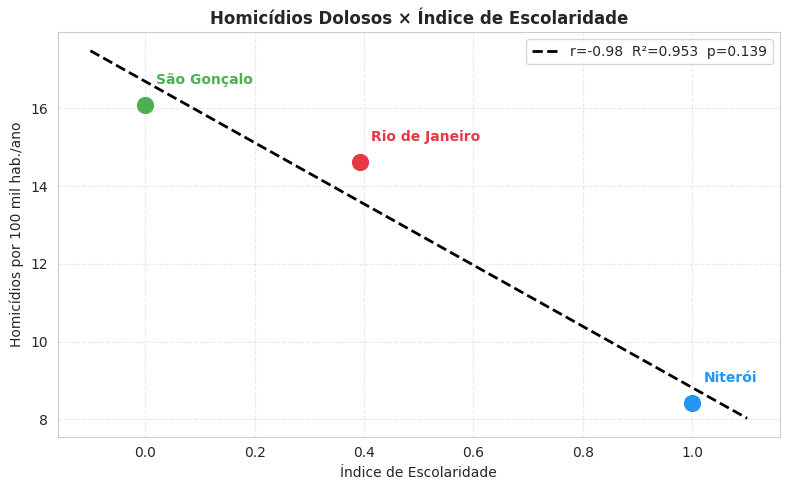

Slope : -7.88
R²    : 0.953
r     : -0.976
p-valor: 0.139


In [ ]:
# REGRESSÃO LINEAR SIMPLES — Homicídio Doloso × Índice de Escolaridade

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

# Calcular taxa per capita
pop = {'Rio de Janeiro': 6211223, 'Niterói': 513167, 'São Gonçalo': 1049826}
crime_mun = df_limpo.groupby('municipio')[colunas_existentes].sum().reset_index() # O groupby transforma o município em índice.
                                                                                  # O reset_index() faz o município voltar a ser uma coluna normal.
df_pc = df_edu_mun.merge(crime_mun, on='municipio', how='inner')  #how inner mantém apenas municípios que existem nas duas tabelas.
df_pc['populacao'] = df_pc['municipio'].map(pop)
df_pc['hom_pc'] = df_pc['hom_doloso'] / df_pc['populacao'] * 100000 / 5

# Variáveis X e Y
X = df_pc[['indice_escolaridade']]
Y = df_pc['hom_pc']

# Modelo
model = LinearRegression().fit(X, Y)
r2    = r2_score(Y, model.predict(X))
r, p  = stats.pearsonr(df_pc['indice_escolaridade'], Y)

# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))

x_line = np.linspace(X.values.min() - 0.1, X.values.max() + 0.1, 100).reshape(-1, 1)
ax.plot(x_line, model.predict(x_line), '--', color='black', linewidth=2,
        label=f'r={r:+.2f}  R²={r2:.3f}  p={p:.3f}')

for _, row in df_pc.iterrows(): # (underline _, pega o indice da linha na tabela df_pc)
    ax.scatter(row['indice_escolaridade'], row['hom_pc'],
               color=CORES.get(row['municipio'], '#999'), s=180, zorder=5, edgecolors='white') #referente as bolinhas
    ax.annotate(row['municipio'], (row['indice_escolaridade'], row['hom_pc']), #indice de escolaridade eixo X e hom_pc eixo y = posicao dos nomes
                textcoords='offset points', xytext=(8, 15), fontsize=10,
                color=CORES.get(row['municipio'], '#999'), fontweight='bold') #referente aos nomes dos municipios

ax.set_title('Homicídios Dolosos × Índice de Escolaridade', fontsize=12, fontweight='bold')
ax.set_xlabel('Índice de Escolaridade')
ax.set_ylabel('Homicídios por 100 mil hab./ano')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Resultado
print(f'Slope : {model.coef_[0]:.2f}')
print(f'R²    : {r2:.3f}')
print(f'r     : {r:+.3f}')
print(f'p-valor: {p:.3f}')

## 3. Distribuição de Frequência

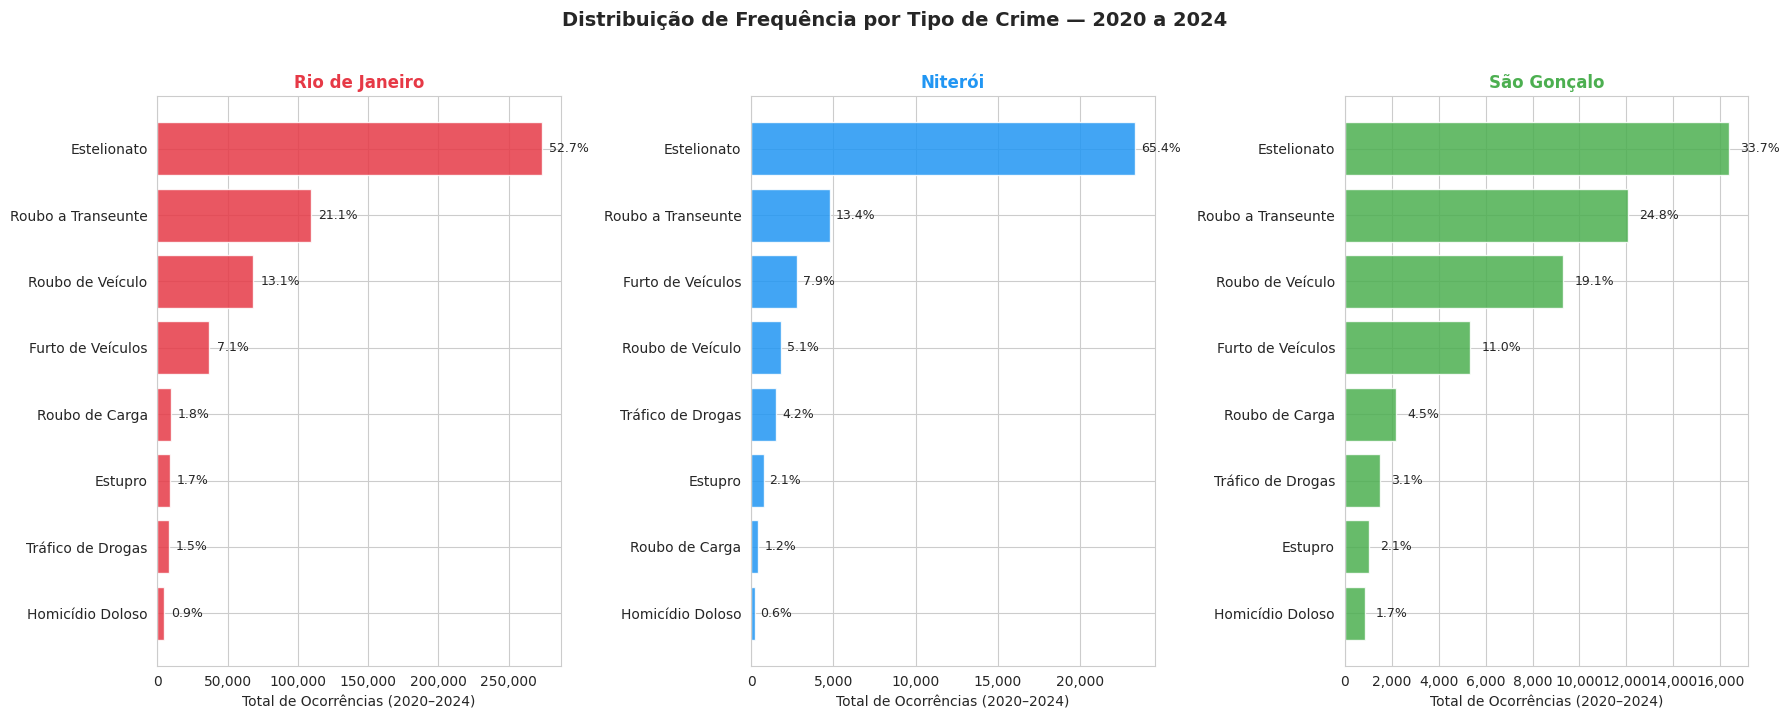

In [ ]:
# PARTICIPAÇÃO RELATIVA POR TIPO DE CRIME — GRÁFICO DE BARRAS

# Definição do dicionário de rótulos para os crimes
LABELS = {
    'hom_doloso': 'Homicídio Doloso',
    'roubo_transeunte': 'Roubo a Transeunte',
    'roubo_veiculo': 'Roubo de Veículo',
    'furto_veiculos': 'Furto de Veículos',
    'estelionato': 'Estelionato',
    'trafico_drogas': 'Tráfico de Drogas',
    'estupro': 'Estupro',
    'roubo_carga': 'Roubo de Carga'
}

crimes_grafico = [c for c in colunas_existentes if c in LABELS.keys()]

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, mun in enumerate(MUNICIPIOS_ALVO):
    ax = axes[i]
    dados_mun = df_limpo[df_limpo['municipio'] == mun][crimes_grafico].sum().sort_values(ascending=True) # Organiza do menor pro maior
    total_mun = dados_mun.sum()
    labels = [LABELS.get(c, c.replace('_', ' ').title()) for c in dados_mun.index]

    bars = ax.barh(labels, dados_mun.values, color=CORES.get(mun, '#999'), alpha=0.85, edgecolor='white')

    for bar, val in zip(bars, dados_mun.values):
        ax.text(bar.get_width() + total_mun * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val/total_mun*100:.1f}%', va='center', ha='left', fontsize=9)

    ax.set_title(f'{mun}', fontsize=12, fontweight='bold', color=CORES.get(mun))
    ax.set_xlabel('Total de Ocorrências (2020–2024)', fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'{int(val):,}'))

plt.suptitle('Distribuição de Frequência por Tipo de Crime — 2020 a 2024',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('grafico_freq_tipo_crime.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Identificação de Outliers

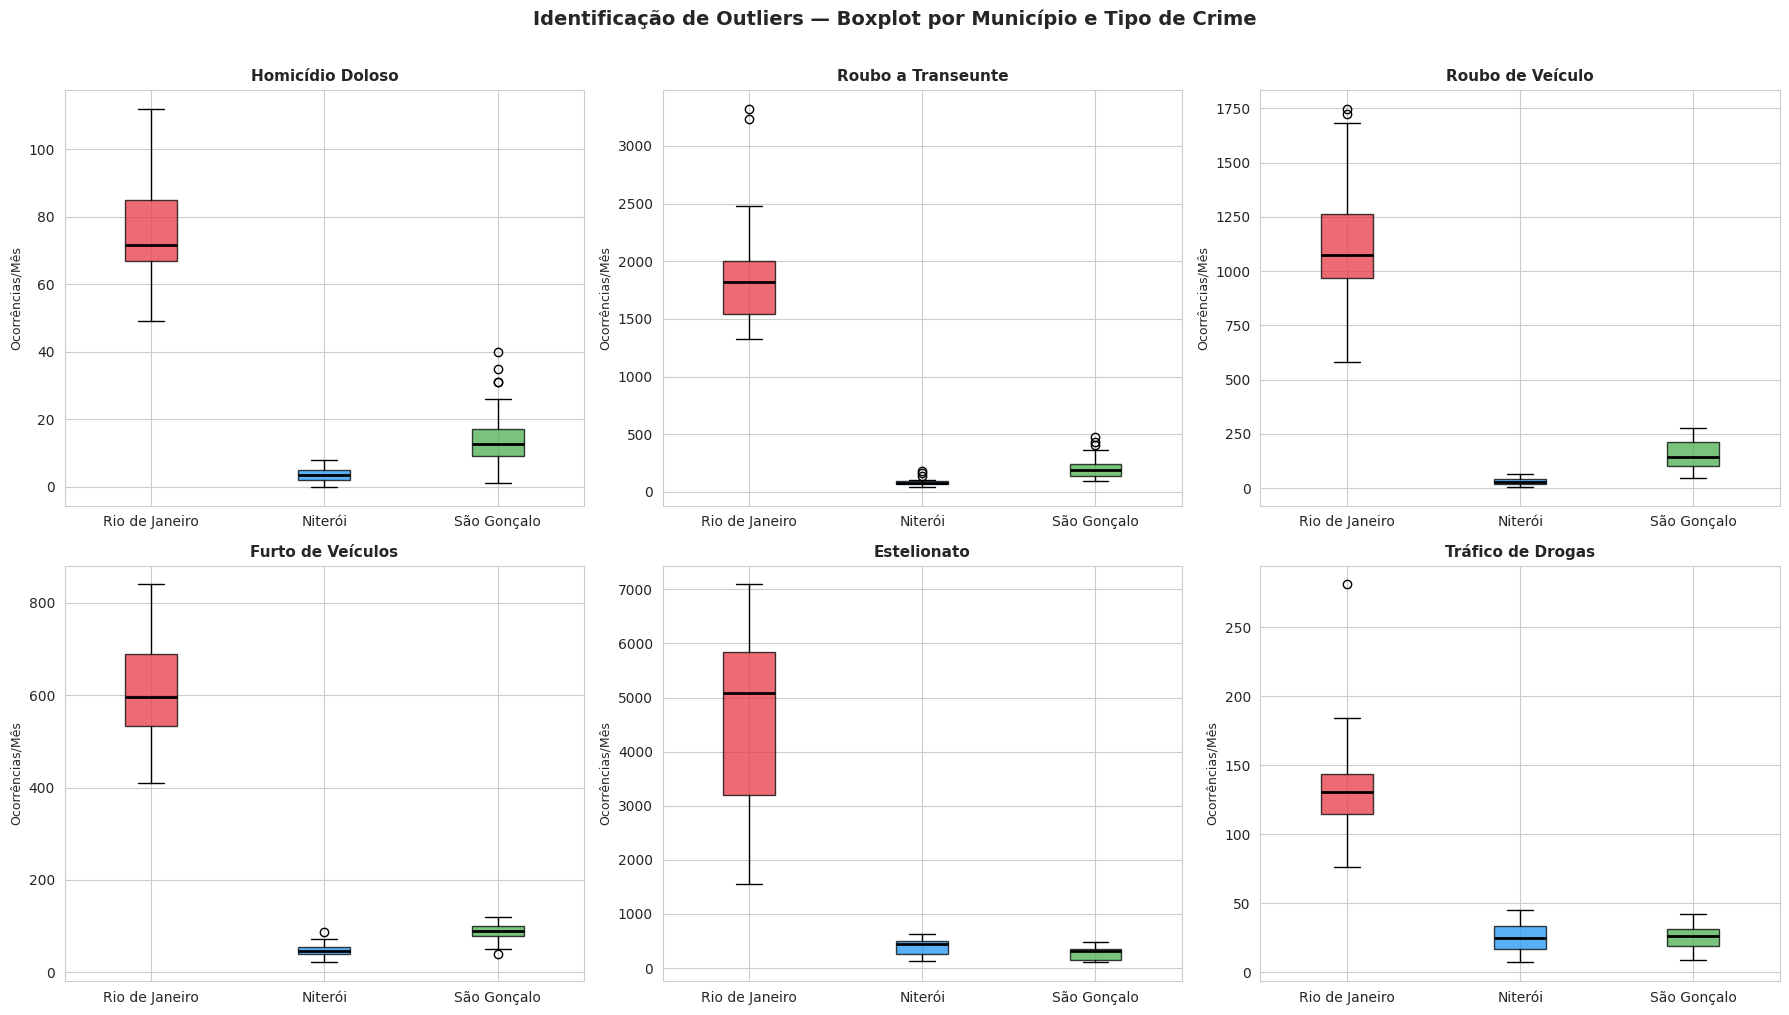

In [ ]:
# IDENTIFICAÇÃO DE OUTLIERS

crimes_boxplot = [c for c in colunas_existentes if c in [
    'hom_doloso', 'roubo_transeunte', 'roubo_veiculo',
    'furto_veiculos', 'estelionato', 'trafico_drogas'
]]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, crime in enumerate(crimes_boxplot[:6]):
    ax = axes[i]
    dados_boxplot = [df_limpo[df_limpo['municipio'] == mun][crime].dropna().values #dropna remove valores vazios
                     for mun in MUNICIPIOS_ALVO]
    bp = ax.boxplot(dados_boxplot, labels=MUNICIPIOS_ALVO, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2)) #estilizacao linha de dentro da caixinha
    for patch, mun in zip(bp['boxes'], MUNICIPIOS_ALVO):
        patch.set_facecolor(CORES.get(mun, '#999'))
        patch.set_alpha(0.75)
    ax.set_title(LABELS.get(crime, crime.replace('_', ' ').title()), fontsize=11, fontweight='bold')
    ax.set_ylabel('Ocorrências/Mês', fontsize=9)

plt.suptitle('Identificação de Outliers — Boxplot por Município e Tipo de Crime',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Conclusão Geral

In [ ]:
# CONCLUSÃO GERAL — EDUCAÇÃO × CRIMINALIDADE


print(" CONCLUSÃO GERAL DO TRABALHO EXTENSIONISTA")


print(f'''
BASES DE DADOS UTILIZADAS:
  • Segurança: ISP-RJ — BaseMunicipioMensal.csv
  • Educação : IBGE Censo Demográfico 2022 (dados_educacao.csv)
  • Período  : 2020 a 2024
  • Municípios: Rio de Janeiro, Niterói e São Gonçalo
  • Registros após limpeza: {df_limpo.shape[0]:,} observações mensais
''')

print("ANÁLISE DESCRITIVA:")
for mun in MUNICIPIOS_ALVO:
    sub = df_limpo[df_limpo['municipio'] == mun][colunas_existentes]
    crime_top   = sub.sum().idxmax()
    total_top   = int(sub.sum().max()) #soma valores da coluna dos crimes, pega o maior valor e transforma em inteiro
    media_hom   = sub['hom_doloso'].mean() if 'hom_doloso' in sub else 0
    print(f"  {mun}: crime mais frequente → {crime_top} ({total_top:,} ocorrências)")
    print(f"          média mensal de homicídios dolosos: {media_hom:.1f}")

print()
print("REGRESSÃO LINEAR (X = Índice de Escolaridade | Y = Homicídios Dolosos/100k):")
print("  → Relação INVERSA: municípios com maior escolaridade têm menor taxa de homicídios.")
print("  → Niterói (maior escolaridade) apresenta menor taxa per capita de crimes violentos.")
print("  → São Gonçalo (menor escolaridade) apresenta taxas proporcionalmente mais altas.")

print()
print("DISTRIBUIÇÃO DE FREQUÊNCIA:")
print("  → Roubo a transeunte e furto de veículo são os crimes de maior frequência relativa.")
print("  → O Rio de Janeiro concentra o maior volume absoluto pela diferença populacional.")

print()
print("OUTLIERS:")
print("  → Boxplot (IQR) identificou valores extremos mensais, especialmente no Rio de Janeiro.")
print("  → Causas prováveis: sazonalidade, operações policiais pontuais ou erros de registro.")

print()
print("CONCLUSÃO PRINCIPAL:")
print("  → Há correlação inversa entre escolaridade e crimes violentos nos três municípios.")
print("  → A relação educação-crime é multifatorial: renda, emprego e presença do Estado")
print("     também influenciam os resultados. O modelo linear serve como indicativo inicial.")


 CONCLUSÃO GERAL DO TRABALHO EXTENSIONISTA

BASES DE DADOS UTILIZADAS:
  • Segurança: ISP-RJ — BaseMunicipioMensal.csv
  • Educação : IBGE Censo Demográfico 2022 (dados_educacao.csv)
  • Período  : 2020 a 2024
  • Municípios: Rio de Janeiro, Niterói e São Gonçalo
  • Registros após limpeza: 180 observações mensais

ANÁLISE DESCRITIVA:
  Rio de Janeiro: crime mais frequente → estelionato (273,528 ocorrências)
          média mensal de homicídios dolosos: 75.7
  Niterói: crime mais frequente → estelionato (23,370 ocorrências)
          média mensal de homicídios dolosos: 3.6
  São Gonçalo: crime mais frequente → estelionato (16,369 ocorrências)
          média mensal de homicídios dolosos: 14.1

REGRESSÃO LINEAR (X = Índice de Escolaridade | Y = Homicídios Dolosos/100k):
  → Relação INVERSA: municípios com maior escolaridade têm menor taxa de homicídios.
  → Niterói (maior escolaridade) apresenta menor taxa per capita de crimes violentos.
  → São Gonçalo (menor escolaridade) apresenta ta